## Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
import copy
import os
import kagglehub

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Model

In [ ]:
'''
Source: https://github.com/akamaster/pytorch_resnet_cifar10/tree/master

Properly implemented ResNet-s for CIFAR10 as described in paper [1].

The implementation and structure of this file is hugely influenced by [2]
which is implemented for ImageNet and doesn't have option A for identity.
Moreover, most of the implementations on the web is copy-paste from
torchvision's resnet and has wrong number of params.

Proper ResNet-s for CIFAR10 (for fair comparision and etc.) has following
number of layers and parameters:

name      | layers | params
ResNet20  |    20  | 0.27M
ResNet32  |    32  | 0.46M
ResNet44  |    44  | 0.66M
ResNet56  |    56  | 0.85M
ResNet110 |   110  |  1.7M
ResNet1202|  1202  | 19.4m

which this implementation indeed has.

Reference:
[1] Kaiming He, Xiangyu Zhang, Shaoqing Ren, Jian Sun
    Deep Residual Learning for Image Recognition. arXiv:1512.03385
[2] https://github.com/pytorch/vision/blob/master/torchvision/models/resnet.py

If you use this implementation in you work, please don't forget to mention the
author, Yerlan Idelbayev.
'''

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init

from torch.autograd import Variable

__all__ = ['ResNet', 'resnet20', 'resnet32', 'resnet44', 'resnet56', 'resnet110', 'resnet1202']

def _weights_init(m):
    classname = m.__class__.__name__
    #print(classname)
    if isinstance(m, nn.Linear) or isinstance(m, nn.Conv2d):
        init.kaiming_normal_(m.weight)

class LambdaLayer(nn.Module):
    def __init__(self, lambd):
        super(LambdaLayer, self).__init__()
        self.lambd = lambd

    def forward(self, x):
        return self.lambd(x)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, option='A'):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            if option == 'A':
                """
                For CIFAR10 ResNet paper uses option A.
                """
                self.shortcut = LambdaLayer(lambda x:
                                            F.pad(x[:, :, ::2, ::2], (0, 0, 0, 0, planes//4, planes//4), "constant", 0))
            elif option == 'B':
                self.shortcut = nn.Sequential(
                     nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                     nn.BatchNorm2d(self.expansion * planes)
                )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=7):
        super(ResNet, self).__init__()
        self.in_planes = 16

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.linear = nn.Linear(64, num_classes)

        self.apply(_weights_init)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion

        return nn.Sequential(*layers)

    def forward(self, x, out_feature=False):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.adaptive_avg_pool2d(out, (1, 1))
        features = out.view(out.size(0), -1)

        if out_feature:
            return features

        out = self.linear(features)
        return out


def resnet20():
    return ResNet(BasicBlock, [3, 3, 3])


def resnet32():
    return ResNet(BasicBlock, [5, 5, 5])


def resnet44():
    return ResNet(BasicBlock, [7, 7, 7])


def resnet56():
    return ResNet(BasicBlock, [9, 9, 9])


def resnet110():
    return ResNet(BasicBlock, [18, 18, 18])


def resnet1202():
    return ResNet(BasicBlock, [200, 200, 200])


def test(net):
    import numpy as np
    total_params = 0

    for x in filter(lambda p: p.requires_grad, net.parameters()):
        total_params += np.prod(x.data.numpy().shape)
    print("Total number of params", total_params)
    print("Total layers", len(list(filter(lambda p: p.requires_grad and len(p.data.size())>1, net.parameters()))))


if __name__ == "__main__":
    for net_name in __all__:
        if net_name.startswith('resnet'):
            print(net_name)
            test(globals()[net_name]())
            print()

resnet20
Total number of params 269239
Total layers 20

resnet32
Total number of params 463671
Total layers 32

resnet44
Total number of params 658103
Total layers 44

resnet56
Total number of params 852535
Total layers 56

resnet110
Total number of params 1727479
Total layers 110

resnet1202
Total number of params 19420791
Total layers 1202



## Functions

In [ ]:
from torch.utils.data import Dataset

class DatasetSplit(Dataset):
    def __init__(self, dataset, idxs):
        self.dataset = dataset
        self.idxs = list(idxs)

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, item):
        image, label = self.dataset[self.idxs[item]]
        return image, label

In [ ]:
class LocalUpdate(object):
  def __init__(self, batchsize, learning_rate, ep, device, dataset=None, idxs=None):
    self.local_bs = batchsize
    self.local_ep = ep
    self.device = device
    self.lr = learning_rate
    self.loss_func = nn.CrossEntropyLoss()
    self.selected_clients = []
    self.ldr_train = DataLoader(DatasetSplit(dataset, idxs), batch_size=self.local_bs, shuffle=True)

  def train(self, model):
    model.train()

    optimizer = torch.optim.SGD(model.parameters(), lr=self.lr, momentum=0.5)
    epoch_loss = []
    for iter in range(self.local_ep):
      batch_loss = []
      for batch_idx, (images, labels) in enumerate(self.ldr_train):
        images, labels = images.to(self.device), labels.to(self.device)
        model.zero_grad()
        log_probs = model(images)
        loss = self.loss_func(log_probs, labels)
        loss.backward()
        optimizer.step()
        batch_loss.append(loss.item())
      epoch_loss.append(sum(batch_loss)/len(batch_loss))
    return model.state_dict(), sum(epoch_loss) / len(epoch_loss)

In [ ]:
def FedAvg(w):
  w_avg = copy.deepcopy(w[0])
  for k in w_avg.keys():
    for i in range(1, len(w)):
      w_avg[k] += w[i][k]
    w_avg[k] = torch.div(w_avg[k], len(w))
  return w_avg

In [ ]:
def train(data_loader, model, criterion, optimizer, epoch, device='cpu'):
    model.train()
    for batch_idx, (inputs, targets) in enumerate(data_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(inputs), len(data_loader.dataset),
                100. * batch_idx / len(data_loader), loss.data.item()))

def inference(data_loader, model, device='cpu'):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(data_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            pred = outputs.data.max(1, keepdim=True)[1]
            correct += pred.eq(targets.data.view_as(pred)).cpu().sum()
            total += targets.size(0)

    print('Test set: Accuracy: {}/{} ({:.2f}%)'.format(
        correct, total, 100* correct/total))
    return correct/total

In [ ]:
def test_img (net_g, dataset, batchsize, device, d_type):
  net_g.eval()
  test_loss = 0
  correct = 0
  data_loader = DataLoader(dataset, batch_size=batchsize)
  l = len(data_loader)
  for idx, (data, target) in enumerate(data_loader):
    data, target = data.to(device), target.to(device)
    log_probs = net_g(data)
    test_loss += F.cross_entropy(log_probs, target, reduction='sum').item()
    y_pred = log_probs.data.max(1, keepdim=True)[1]
    correct += y_pred.eq(target.data.view_as(y_pred)).long().cpu().sum()
  test_loss /= len(data_loader.dataset)
  accuracy = 100.00 * correct / len(data_loader.dataset)
  print('\n{} Set: Average loss: {:.4f} \nAccuracy: {}/{} ({:.2f}%)\n'.format(
      d_type, test_loss, correct, len(data_loader.dataset), accuracy)
  )
  return accuracy, test_loss

## Dataset

In [ ]:
path = kagglehub.dataset_download("hylanj/wifi-csi-dataset-ut-har")
print("Path to dataset files:", path)

100%|██████████| 368M/368M [00:02<00:00, 135MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/hylanj/wifi-csi-dataset-ut-har/versions/1


In [ ]:
class UT_HAR_Dataset(Dataset):
    def __init__(self, data_path, label_path):
        print(f"Loading {data_path} as binary...")

        try:
            self.x_data = np.load(data_path).astype('float32')
            self.y_data = np.load(label_path).astype('int64').flatten()
        except ValueError:
            # Fallback for raw binary if np.load fails
            self.x_data = np.fromfile(data_path, dtype='float32')
            self.x_data = self.x_data.reshape(-1, 90)
            self.y_data = np.fromfile(label_path, dtype='int64').flatten()

        print(f"Successfully loaded {len(self.x_data)} samples.")

        if self.y_data.min() == 1:
            self.y_data -= 1

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx):
        sample = torch.tensor(self.x_data[idx]).unsqueeze(0)
        label = torch.tensor(self.y_data[idx])
        return sample, label

In [ ]:
data_dir = os.path.join(path, 'data')
label_dir = os.path.join(path, 'label')

train_dataset = UT_HAR_Dataset(
    os.path.join(data_dir, 'X_train.csv'),
    os.path.join(label_dir, 'y_train.csv')
)

test_dataset = UT_HAR_Dataset(
    os.path.join(data_dir, 'X_test.csv'),
    os.path.join(label_dir, 'y_test.csv')
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Loading /root/.cache/kagglehub/datasets/hylanj/wifi-csi-dataset-ut-har/versions/1/data/X_train.csv as binary...
Successfully loaded 3977 samples.
Loading /root/.cache/kagglehub/datasets/hylanj/wifi-csi-dataset-ut-har/versions/1/data/X_test.csv as binary...
Successfully loaded 500 samples.


## Simulating IID and Non-IID Data

In [ ]:
def csi_iid(dataset, num_users):
  num_items = int(len(dataset)/num_users)
  dict_users, all_idxs = {}, [i for i in range(len(dataset))]

  for i in range(num_users):
    dict_users[i] = set(np.random.choice(all_idxs, num_items, replace=False))
    all_idxs = list(set(all_idxs)-dict_users[i])
  return dict_users

def csi_noniid(dataset, num_users):
  num_shards = num_users * 2
  num_imgs = int(len(dataset) / num_shards)
  idx_shard = [i for i in range(num_shards)]
  dict_users = {i: np.array([], dtype='int64') for i in range(num_users)}
  idxs = np.arange(num_shards * num_imgs)
  labels = dataset.y_data

  # Sort indices by label
  idxs_labels = np.vstack((np.arange(len(labels)), labels))
  idxs_labels = idxs_labels[:, idxs_labels[1, :].argsort()]
  idxs = idxs_labels[0, :]

  # Divide shards across users
  for i in range(num_users):
      rand_set = set(np.random.choice(idx_shard, 2, replace=False))
      idx_shard = list(set(idx_shard) - rand_set)
      for rand in rand_set:
          dict_users[i] = np.concatenate((dict_users[i], idxs[rand*num_imgs:(rand+1)*num_imgs]), axis=0)
  return dict_users

In [ ]:
num_users = 100

dict_users = csi_iid(train_dataset, num_users)
# dict_users = csi_noniid(train_dataset, num_users)

## Supervised Training and Evaluation

In [ ]:
# Hyper-parameters
epochs = 100
ep = 10
batchsize = 64
learning_rate = 0.01
frac = .1
net_glob = resnet20().to(device)

Round   0, Average loss 1.645

Train Set: Average loss: 4.9228 
Accuracy: 1172/3977 (29.47%)


Test Set: Average loss: 5.0287 
Accuracy: 147/500 (29.40%)

-------------------------------


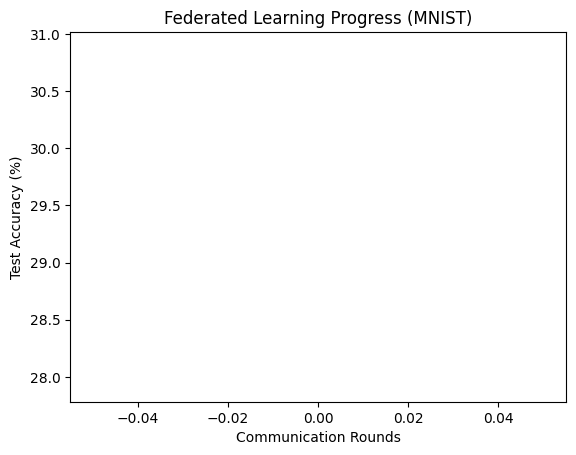

In [ ]:
acc_hist = []

for iter in range(epochs):
  w_locals, loss_locals = [], []
  m = max(int(num_users * frac), 1)
  idxs_users = np.random.choice(range(num_users), m, replace=False)

  for idx in idxs_users:
    # print("The current node number:", idx)
    local = LocalUpdate(batchsize, learning_rate, ep, device,
                        dataset=train_dataset, idxs=dict_users[idx])
    w, loss = local.train(model=copy.deepcopy(net_glob).to(device))
    w_locals.append(copy.deepcopy(w))
    loss_locals.append(copy.deepcopy(loss))

  w_glob = FedAvg(w_locals)
  net_glob.load_state_dict(w_glob)

  loss_avg = sum(loss_locals) / len(loss_locals)
  print('Round {:3d}, Average loss {:.3f}'.format(iter, loss_avg))

  net_glob.eval()
  acc_train, loss_train = test_img(net_glob, train_dataset, batchsize=batchsize,
                                   device=device, d_type="Train")
  acc_test, loss_test = test_img(net_glob, test_dataset, batchsize=batchsize,
                                 device=device, d_type="Test")
  acc_hist.append(acc_test)

  # print("Training Accuracy: {:.2f}%".format(acc_train))
  # print("Testing Accuracy: {:.2f}%".format(acc_test))

  with open('./results.txt', 'a') as f:
    f.write(f'\n{acc_test}')

  print("-------------------------------")

plt.plot(range(epochs), acc_hist)
plt.xlabel('Communication Rounds')
plt.ylabel('Test Accuracy (%)')
plt.title('Federated Learning Progress (MNIST)')
plt.show()

## Graphing IID and Non-IID Results
I did not use the most effective way to store these values. For each test, I had the array `acc_hist` copied under the corresponding label below. I manually ran each test and stored its value in each of these variables. Remember to have only the corresponding label uncommented as to not overwrite and lose previously stored arrays.

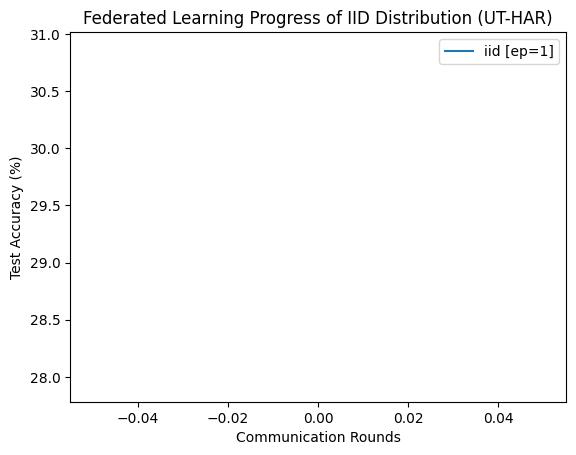

In [ ]:
data_ep1 = copy.deepcopy(acc_hist)
# data_ep3 = copy.deepcopy(acc_hist)
# data_ep5 = copy.deepcopy(acc_hist)

plt.plot(range(epochs), data_ep1)
plt.plot(range(epochs), data_ep3)
plt.plot(range(epochs), data_ep5)

plt.legend(['iid [ep=1]', 'iid [ep=3]', 'iid [ep=5]'])
plt.xlabel('Communication Rounds')
plt.ylabel('Test Accuracy (%)')
plt.title('Federated Learning Progress of IID Distribution (UT-HAR)')
plt.show()

# non_data_ep1 = copy.deepcopy(acc_hist)
# non_data_ep3 = copy.deepcopy(acc_hist)
# non_data_ep5 = copy.deepcopy(acc_hist)

# plt.plot(range(epochs), non_data_ep1)
# plt.plot(range(epochs), non_data_ep3)
# plt.plot(range(epochs), non_data_ep5)

# plt.legend(['non-iid [ep=1]', 'non-iid [ep=3]', 'non-iid [ep=5]'])
# plt.xlabel('Communication Rounds')
# plt.ylabel('Test Accuracy (%)')
# plt.title('Federated Learning Progress of Non-IID Distribution (UT-HAR)')
# plt.show()

## Unsupervised Learning (FedX)

In [ ]:
class ContrastiveLoss(torch.nn.Module):
    def __init__(self, temperature=0.1):
        super().__init__()
        self.temperature = temperature
        self.criterion = torch.nn.CrossEntropyLoss(reduction="sum")

    def forward(self, z_i, z_j):
        # Batch and find similarities
        batch_size = z_i.shape[0]
        N = 2 * batch_size
        z = torch.cat((z_i, z_j), dim=0)
        z = F.normalize(z, dim=1)
        sim = torch.matmul(z, z.T) / self.temperature

        # Generate mask for negative pair
        mask = torch.ones((N, N), dtype=bool, device=z.device)
        mask = mask.fill_diagonal_(0)
        for i in range(batch_size):
            mask[i, batch_size + i] = 0
            mask[batch_size + i, i] = 0

        # Evaluate positive and negative pairs
        sim_i_j = torch.diag(sim, batch_size)
        sim_j_i = torch.diag(sim, -batch_size)
        positives = torch.cat((sim_i_j, sim_j_i), dim=0).view(N, 1)
        negatives = sim[mask].view(N, -1)
        logits = torch.cat((positives, negatives), dim=1)
        labels = torch.zeros(N, device=z.device).long()

        return self.criterion(logits, labels) / N

In [ ]:
class LocalContrastiveUpdate(object):
  def __init__(self, batchsize, learning_rate, ep, device, global_net,
               dataset=None, idxs=None):
    self.local_bs = batchsize
    self.local_ep = ep
    self.device = device
    self.g_model = global_net
    self.lr = learning_rate
    self.constrastiveCriterion = ContrastiveLoss(batchsize)
    self.selected_clients = []
    self.ldr_train = DataLoader(DatasetSplit(dataset, idxs), batch_size=self.local_bs, shuffle=True)

  def augment(self, csi_tensor, noise_level=0.01, mask_ratio=0.1):
    # csi_tensor shape: [1, 250, 90]
    aug_csi = csi_tensor.clone()

    # Add Gaussian Noise
    noise = torch.randn_like(aug_csi) * noise_level
    aug_csi = aug_csi + noise

    # Time Masking (Zeroing out random time steps [x] )
    time_steps = aug_csi.shape[1]
    num_mask = int(time_steps * mask_ratio)
    start = np.random.randint(0, time_steps - num_mask)
    aug_csi[:, start:start+num_mask, :] = 0

    # Frequency Masking (Zeroing out random subcarriers [y] )
    subcarriers = aug_csi.shape[2]
    num_mask_sub = int(subcarriers * mask_ratio)
    start_sub = np.random.randint(0, subcarriers - num_mask_sub)
    aug_csi[:, :, start_sub:start_sub+num_mask_sub] = 0

    return aug_csi

  def train(self, model):
    model.train()
    optimizer = torch.optim.SGD(model.parameters(), lr=self.lr, momentum=0.5)
    epoch_loss = []
    for iter in range(self.local_ep):
      batch_loss = []
      for batch_idx, (images, ___) in enumerate(self.ldr_train):
        images = images.to(self.device)

        v1 = self.augment(images)
        v2 = self.augment(images)

        model.zero_grad()
        v1_result = model(v1, out_feature=True)
        v2_result = model(v2, out_feature=True)
        loss = self.constrastiveCriterion(v1_result, v2_result)

        with torch.no_grad():
          g_result = self.g_model(v1, out_feature=True)

        loss_fedx = F.mse_loss(v1_result, g_result)
        total_loss = loss + loss_fedx
        total_loss.backward()
        optimizer.step()

        batch_loss.append(loss.item())
      epoch_loss.append(sum(batch_loss)/len(batch_loss))
    return model.state_dict(), sum(epoch_loss) / len(epoch_loss)

The results in the paper used the non-IID data distribution. However, using both IID and non-IID simulations resulting in the same accuracy in my experience.

In [ ]:
num_users = 100

# dict_users = csi_iid(train_dataset, num_users)
dict_users = csi_noniid(train_dataset, num_users)

In [ ]:
epochs = 100
ep = 3
num_users = 100
batchsize = 64
learning_rate = 0.001
frac = .1
net_glob = resnet20().to(device)

Round   0, Average loss 4.317


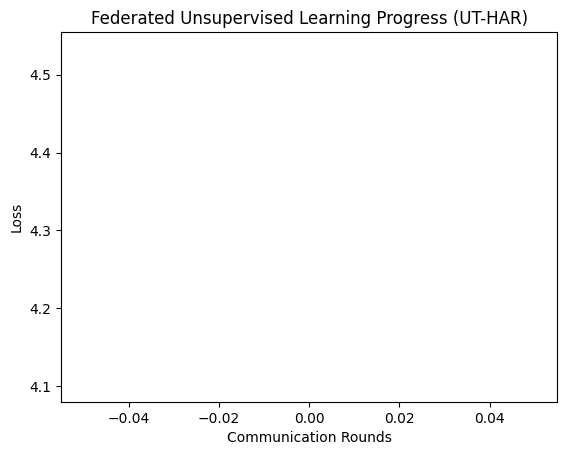

In [ ]:
acc_hist = []

for iter in range(epochs):
  w_locals, loss_locals = [], []
  m = max(int(num_users * frac), 1)
  idxs_users = np.random.choice(range(num_users), m, replace=False)
  for idx in idxs_users:
    # print("The current node number:", idx)
    local = LocalContrastiveUpdate(batchsize, learning_rate, ep, device,
                                   global_net=net_glob, dataset=train_dataset,
                                   idxs=dict_users[idx])
    w, loss = local.train(model=copy.deepcopy(net_glob).to(device))
    w_locals.append(copy.deepcopy(w))
    loss_locals.append(copy.deepcopy(loss))
  w_glob = FedAvg(w_locals)
  net_glob.load_state_dict(w_glob)

  # Loss will largely remain around 4 since this is unsupervised
  loss_avg = sum(loss_locals) / len(loss_locals)
  print('Round {:3d}, Average loss {:.3f}'.format(iter, loss_avg))
  acc_hist.append(loss_avg)

# Graph will not result in any meaningful information
plt.plot(range(epochs), acc_hist)
plt.xlabel('Communication Rounds')
plt.ylabel('Loss')
plt.title('Federated Unsupervised Learning Progress (UT-HAR)')
plt.show()

## Unsupervised Evaluation

In [ ]:
def evaluate_unsupervised(net_glob, train_loader, test_loader, device):
    # Freeze all weights, we only want to train the last layer
    for param in net_glob.parameters():
        param.requires_grad = False

    # Re-initialize the final layer
    net_glob.linear = nn.Sequential(
                          nn.Linear(64, 128),
                          nn.ReLU(),
                          nn.Dropout(0.2),
                          nn.Linear(128, 7)
                      ).to(device)
    for param in net_glob.linear.parameters():
        param.requires_grad = True

    optimizer = torch.optim.Adam(net_glob.linear.parameters(), lr=0.01)
    criterion = torch.nn.CrossEntropyLoss()

    net_glob.train()
    for epoch in range(30):
      train(train_loader, net_glob, criterion, optimizer, epoch, device)

    net_glob.eval()
    acc_train, loss_train = test_img(net_glob, train_dataset, batchsize=batchsize,
                                   device=device, d_type="Train")
    acc_test, loss_test = test_img(net_glob, test_dataset, batchsize=batchsize,
                                 device=device, d_type="Test")

In [ ]:
def plot_confusion_matrix(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    gesture_names = ['L0', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=gesture_names, yticklabels=gesture_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Gesture Recognition Confusion Matrix')
    plt.show()

In [ ]:
# Copy the model so we can return to the final unsupervised model
copy_model = copy.deepcopy(net_glob)

evaluate_unsupervised(copy_model, train_loader, test_loader, device)

Train Epoch: 0 [0/3977 (0%)]	Loss: 1.975429
Train Epoch: 1 [0/3977 (0%)]	Loss: 1.688085
Train Epoch: 2 [0/3977 (0%)]	Loss: 1.541225
Train Epoch: 3 [0/3977 (0%)]	Loss: 1.663958
Train Epoch: 4 [0/3977 (0%)]	Loss: 1.701549
Train Epoch: 5 [0/3977 (0%)]	Loss: 1.578349
Train Epoch: 6 [0/3977 (0%)]	Loss: 1.532794
Train Epoch: 7 [0/3977 (0%)]	Loss: 1.349351
Train Epoch: 8 [0/3977 (0%)]	Loss: 1.404544
Train Epoch: 9 [0/3977 (0%)]	Loss: 1.788364
Train Epoch: 10 [0/3977 (0%)]	Loss: 1.478858
Train Epoch: 11 [0/3977 (0%)]	Loss: 1.487230
Train Epoch: 12 [0/3977 (0%)]	Loss: 1.454937
Train Epoch: 13 [0/3977 (0%)]	Loss: 1.568219
Train Epoch: 14 [0/3977 (0%)]	Loss: 1.564182
Train Epoch: 15 [0/3977 (0%)]	Loss: 1.304597
Train Epoch: 16 [0/3977 (0%)]	Loss: 1.697889
Train Epoch: 17 [0/3977 (0%)]	Loss: 1.673078
Train Epoch: 18 [0/3977 (0%)]	Loss: 1.346219
Train Epoch: 19 [0/3977 (0%)]	Loss: 1.495620
Train Epoch: 20 [0/3977 (0%)]	Loss: 1.470511
Train Epoch: 21 [0/3977 (0%)]	Loss: 1.278048
Train Epoch: 22 [0/3

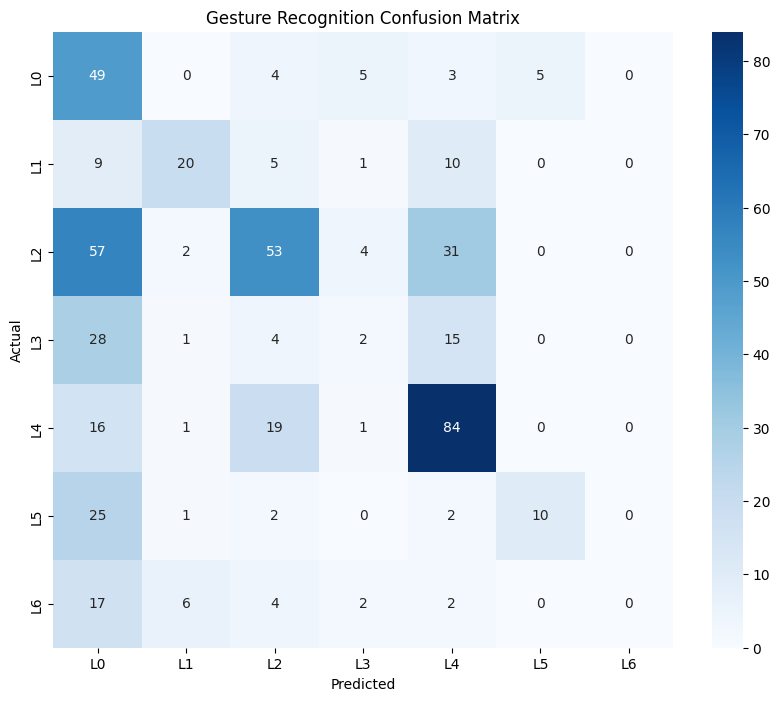

In [ ]:
plot_confusion_matrix(copy_model, test_loader, device)

In [ ]:
inference(test_loader, copy_model, device)

Test set: Accuracy: 218/500 (43.60%)


tensor(0.4360)